In [1]:
import numpy as np
import pandas as pd
import joblib
import pickle
import os
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
MODELS_DIR  = '../outputs/models/'
OUTPUTS_DIR = '../outputs/evaluation/'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [3]:
targets      = ['avg_d_mbps', 'avg_u_mbps', 'avg_lat_ms']
target_names = ['Download (Mbps)', 'Upload (Mbps)', 'Latency (ms)']
model_names  = ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']

In [4]:
X_test  = np.load(os.path.join(MODELS_DIR, 'X_test.npy'), allow_pickle=True)
y_test  = np.load(os.path.join(MODELS_DIR, 'y_test.npy'), allow_pickle=True)

In [5]:
y_test_df = pd.DataFrame(y_test, columns=targets)

In [6]:
with open(os.path.join(MODELS_DIR, 'scaler_X.pkl'), 'rb') as f:
    scaler_X = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'scalers_y.pkl'), 'rb') as f:
    scalers_y = pickle.load(f)

In [7]:
X_test_scal = scaler_X.transform(X_test)   # scaled version for LR

C:\Users\fatma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [8]:
y_test_df.describe().round(3)

,avg_d_mbps,avg_u_mbps,avg_lat_ms
count,913.000,913.000,913.000
mean,161.823,23.651,27.529
std,121.374,12.757,42.056
min,0.914,0.096,9.000
25%,64.692,14.541,17.000
50%,137.800,21.704,20.000
75%,238.150,30.117,24.333
max,918.761,92.192,739.000


In [9]:
lr_models = joblib.load(os.path.join(MODELS_DIR, 'lr_models.pkl'))
dt_models = joblib.load(os.path.join(MODELS_DIR, 'dt_models.pkl'))
rf_models = joblib.load(os.path.join(MODELS_DIR, 'rf_models.pkl'))
gb_models = joblib.load(os.path.join(MODELS_DIR, 'gb_models.pkl'))

In [10]:
def predict_lr(models, X_scal, scalers_y, targets):
    arr = np.zeros((len(X_scal), len(targets)))
    for i, target in enumerate(targets):
        y_pred_s = models[target].predict(X_scal)
        y_pred   = scalers_y[target].inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
        arr[:, i] = np.clip(y_pred, 0, None)
    return arr

In [11]:
def predict_tree(models, X, targets):
    arr = np.zeros((len(X), len(targets)))
    for i, target in enumerate(targets):
        arr[:, i] = np.clip(models[target].predict(X), 0, None)
    return arr

In [12]:
def predict_gb_log(models, X, targets):
    arr = np.zeros((len(X), len(targets)))
    for i, target in enumerate(targets):
        y_pred_log = models[target].predict(X)
        arr[:, i]  = np.clip(np.expm1(y_pred_log), 0, None)
    return arr

In [13]:
test_preds = {
    'Linear Regression' : predict_lr(lr_models,   X_test_scal, scalers_y, targets),
    'Decision Tree'     : predict_tree(dt_models,  X_test,      targets),
    'Random Forest'     : predict_tree(rf_models,  X_test,      targets),
    'Gradient Boosting' : predict_gb_log(gb_models, X_test,     targets),
}

C:\Users\fatma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\fatma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\fatma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\fatma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\fatma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn

In [14]:
def compute_metrics(y_true_df, y_pred_arr, targets):
    result = {}
    for i, target in enumerate(targets):
        yt    = y_true_df.iloc[:, i]
        yp    = y_pred_arr[:, i]
        valid = yt > 0  
        result[target] = {
            'MAE' : round(float(mean_absolute_error(yt, yp)), 3),
            'RMSE': round(float(np.sqrt(mean_squared_error(yt, yp))), 3),
            'MAPE': round(float(mean_absolute_percentage_error(yt[valid], yp[valid])) * 100, 2),
            'R2'  : round(float(r2_score(yt, yp)), 4),
        }
    return result

In [15]:
all_test_metrics = {
    name: compute_metrics(y_test_df, test_preds[name], targets)
    for name in model_names
}

In [16]:
metrics_order = ['MAE', 'RMSE', 'MAPE', 'R2']

In [17]:
for target in targets:
    rows = []
    for name in model_names:
        row = {'Model': name}
        row.update(all_test_metrics[name][target])
        rows.append(row)
    df = pd.DataFrame(rows).set_index('Model')
    print(f'\n── {target} ──')
    display(df)


── avg_d_mbps ──


,MAE,RMSE,MAPE,R2
Model,,,,
Linear Regression,52.581,83.581,78.77,0.5253
Decision Tree,51.783,84.036,63.30,0.5201
Random Forest,49.498,80.641,70.44,0.5581
Gradient Boosting,47.912,84.411,45.75,0.5158



── avg_u_mbps ──


,MAE,RMSE,MAPE,R2
Model,,,,
Linear Regression,6.204,9.237,66.19,0.4752
Decision Tree,6.764,9.985,75.56,0.3867
Random Forest,6.107,9.212,69.80,0.4780
Gradient Boosting,6.050,9.293,49.48,0.4687



── avg_lat_ms ──


,MAE,RMSE,MAPE,R2
Model,,,,
Linear Regression,11.254,39.214,34.50,0.1296
Decision Tree,10.828,36.876,32.22,0.2304
Random Forest,10.588,35.935,32.36,0.2691
Gradient Boosting,9.569,35.720,24.45,0.2778


In [18]:
metric_weights = [
    ('MAPE', 3, True),
    ('R2',   2, False),
    ('RMSE', 1, True),
    ('MAE',  1, True),
]

In [19]:
total_rank = {name: 0 for name in model_names}

In [26]:
for target in targets:
    for metric, weight, lower_better in metric_weights:
        ordered = sorted(
            model_names,
            key=lambda n: all_test_metrics[n][target][metric],
            reverse=not lower_better
        )
        for pos, name in enumerate(ordered, start=1):
            total_rank[name] += pos * weight

ranked      = sorted(total_rank.items(), key=lambda x: x[1])
winner_name = ranked[0][0]

In [21]:
ranked

[('Gradient Boosting', 36),
 ('Random Forest', 45),
 ('Decision Tree', 64),
 ('Linear Regression', 65)]

In [22]:
winner_name

'Gradient Boosting'

In [28]:
OUTPUTS_DIR

'../outputs/evaluation/'

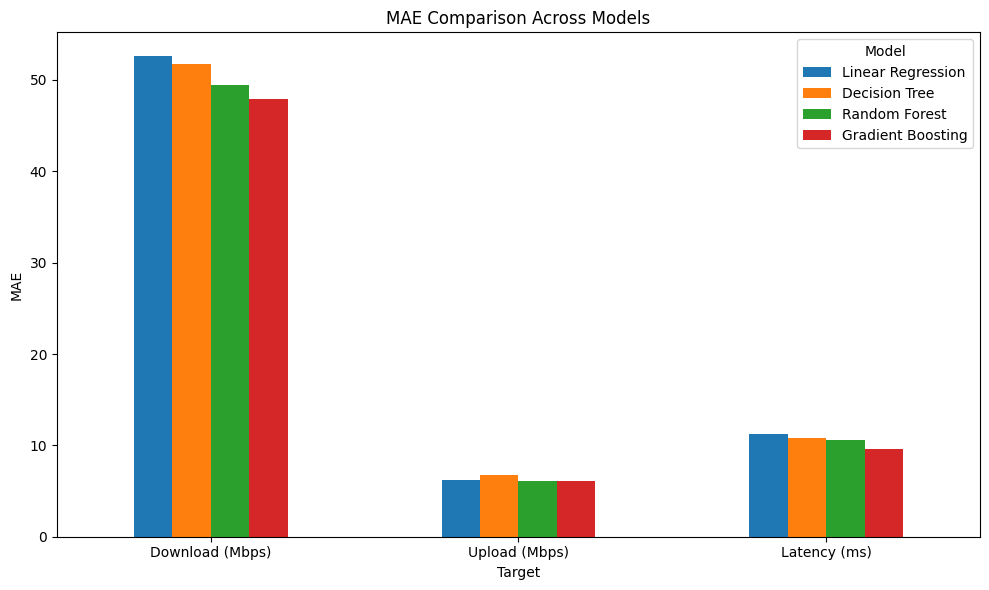

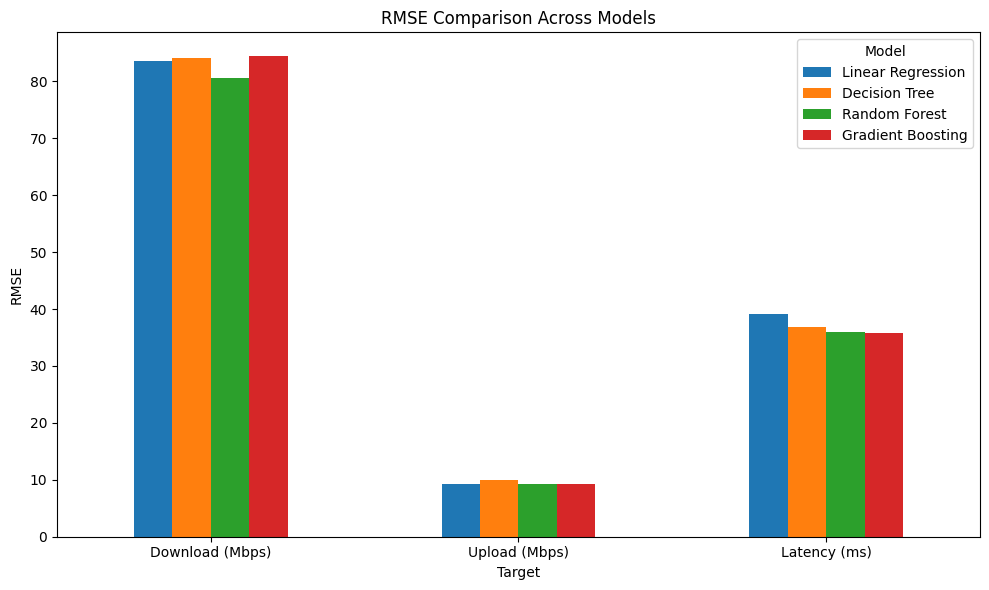

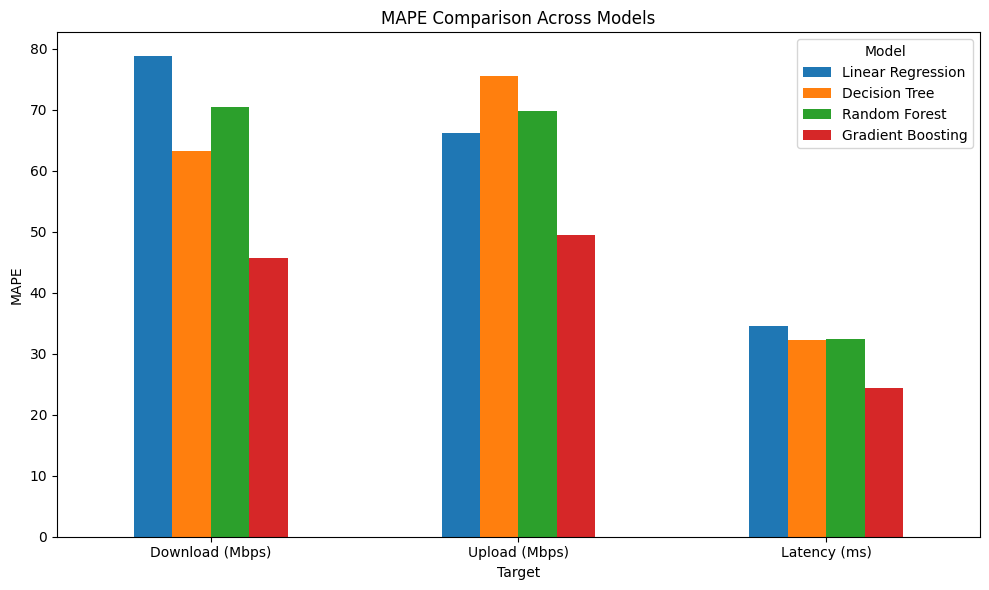

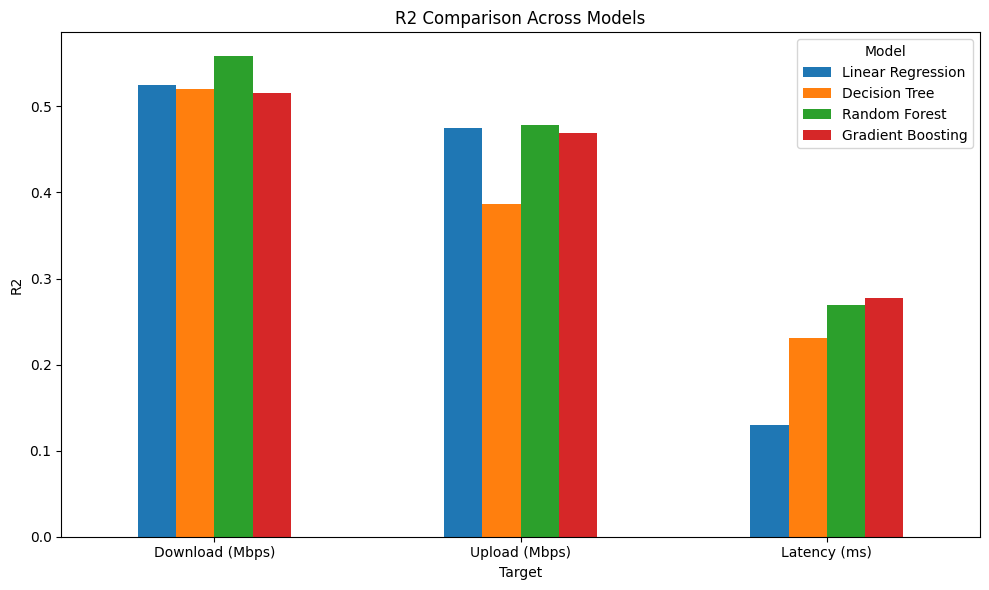

In [27]:
metrics_order = ['MAE', 'RMSE', 'MAPE', 'R2']

for metric in metrics_order:
    rows = []
    for target, target_label in zip(targets, target_names):
        row = {'Target': target_label}
        for model in model_names:
            row[model] = all_test_metrics[model][target][metric]
        rows.append(row)

    plot_df = pd.DataFrame(rows).set_index('Target')

    ax = plot_df.plot(kind='bar', figsize=(10, 6))
    plt.title(f'{metric} Comparison Across Models')
    plt.xlabel('Target')
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.legend(title='Model')
    plt.tight_layout()

    plt.savefig(os.path.join(OUTPUTS_DIR, f'{metric.lower()}_comparison.png'), dpi=200, bbox_inches='tight')
    plt.show()

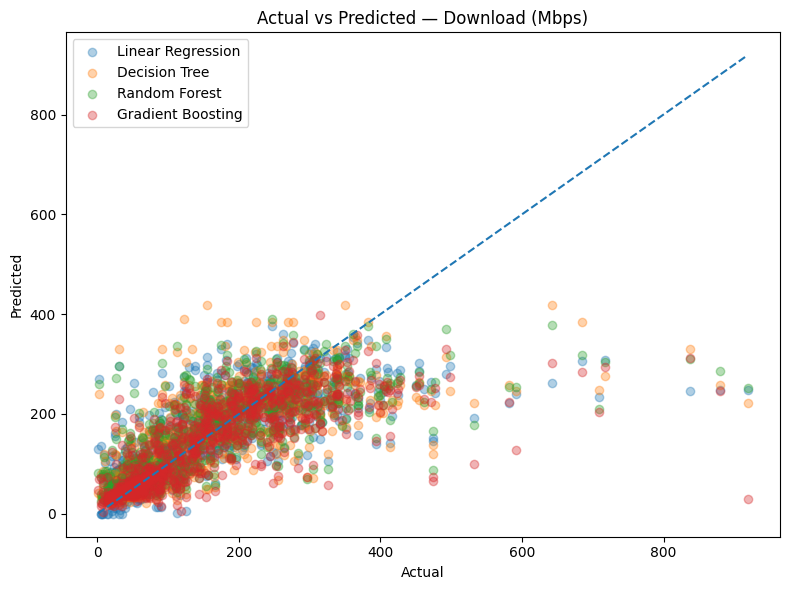

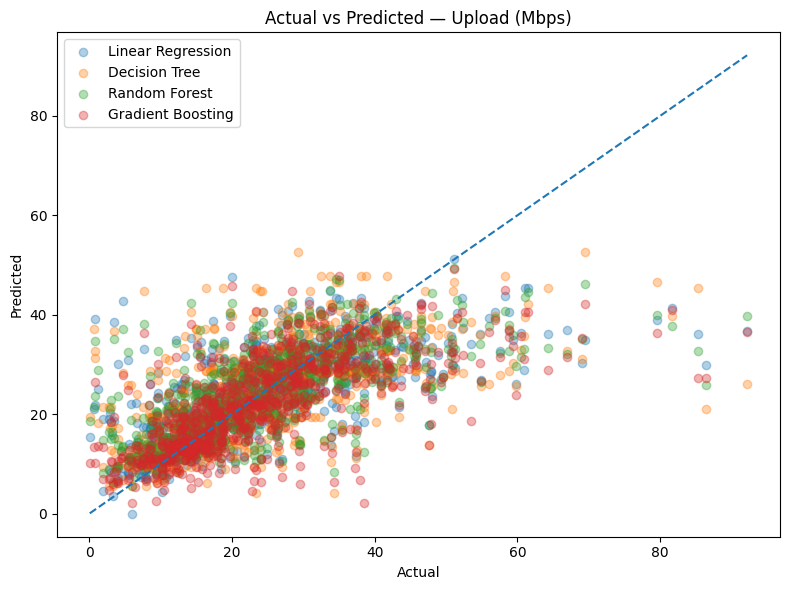

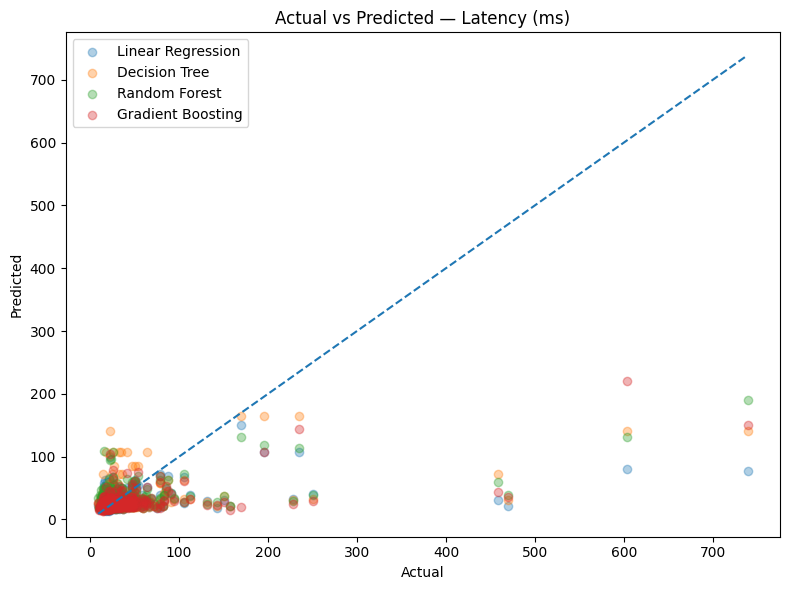

In [29]:
for i, (target, target_label) in enumerate(zip(targets, target_names)):
    plt.figure(figsize=(8, 6))

    y_true = y_test_df[target].values

    for model in model_names:
        y_pred = test_preds[model][:, i]
        plt.scatter(y_true, y_pred, alpha=0.35, label=model)

    min_val = y_true.min()
    max_val = y_true.max()
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    plt.title(f'Actual vs Predicted — {target_label}')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.legend()
    plt.tight_layout()

    safe_name = target.replace('/', '_')
    plt.savefig(os.path.join(OUTPUTS_DIR, f'actual_vs_predicted_{safe_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()

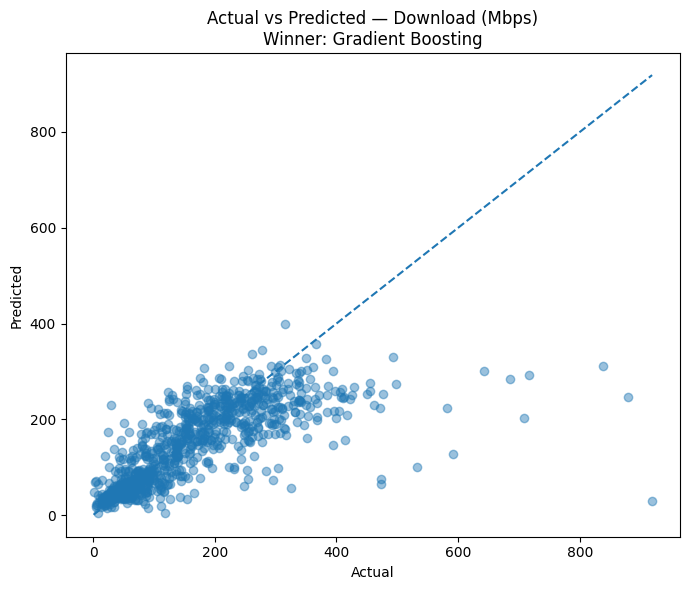

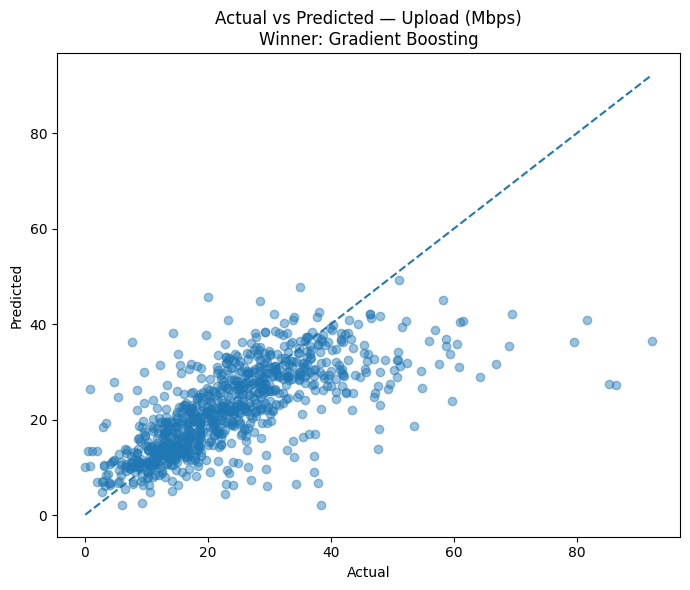

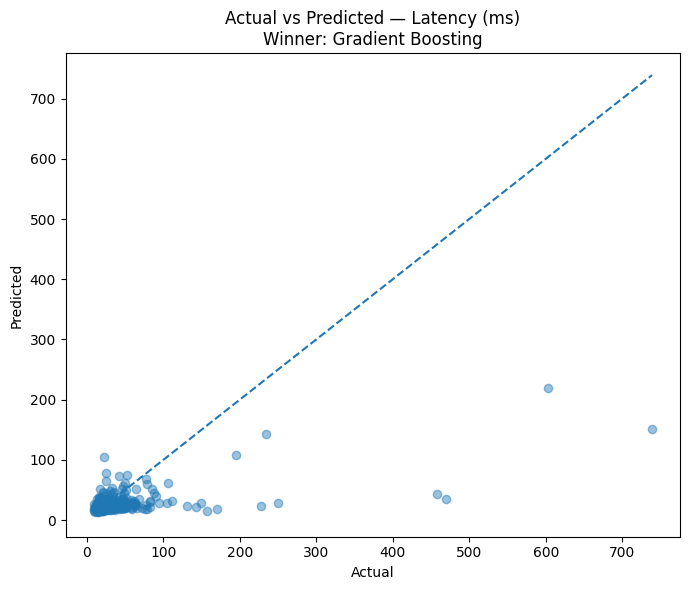

In [30]:
for i, (target, target_label) in enumerate(zip(targets, target_names)):
    y_true = y_test_df[target].values
    y_pred = test_preds[winner_name][:, i]

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.45)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    plt.title(f'Actual vs Predicted — {target_label}\nWinner: {winner_name}')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()

    safe_name = target.replace('/', '_')
    plt.savefig(os.path.join(OUTPUTS_DIR, f'winner_actual_vs_predicted_{safe_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()

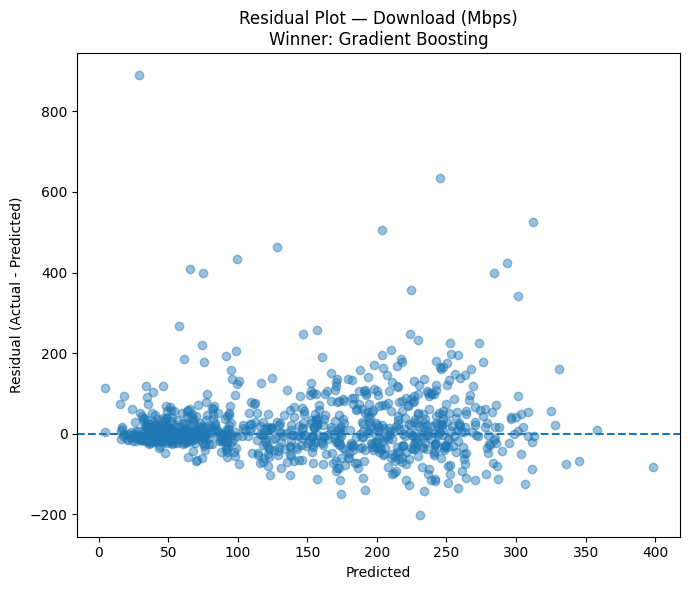

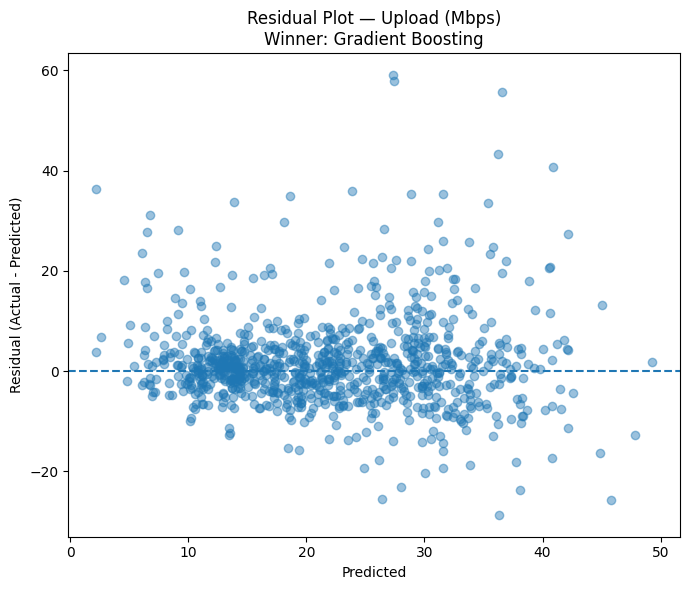

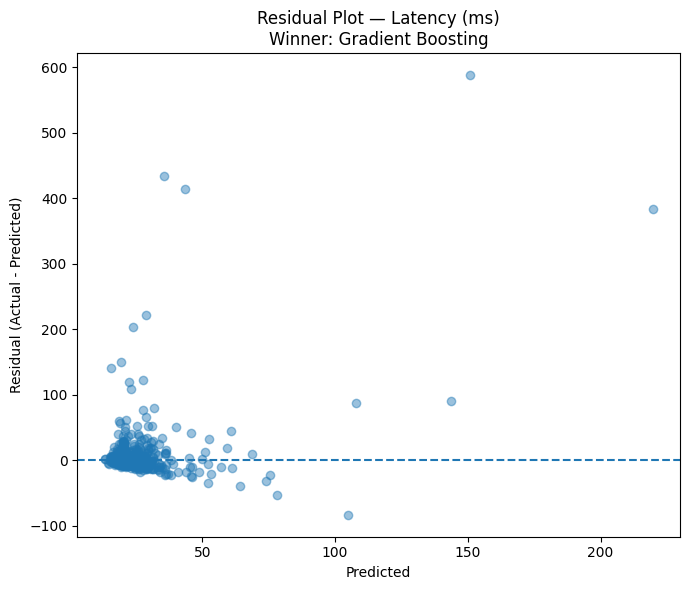

In [31]:
for i, (target, target_label) in enumerate(zip(targets, target_names)):
    y_true = y_test_df[target].values
    y_pred = test_preds[winner_name][:, i]
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 6))
    plt.scatter(y_pred, residuals, alpha=0.45)
    plt.axhline(0, linestyle='--')

    plt.title(f'Residual Plot — {target_label}\nWinner: {winner_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual - Predicted)')
    plt.tight_layout()

    safe_name = target.replace('/', '_')
    plt.savefig(os.path.join(OUTPUTS_DIR, f'winner_residual_plot_{safe_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()

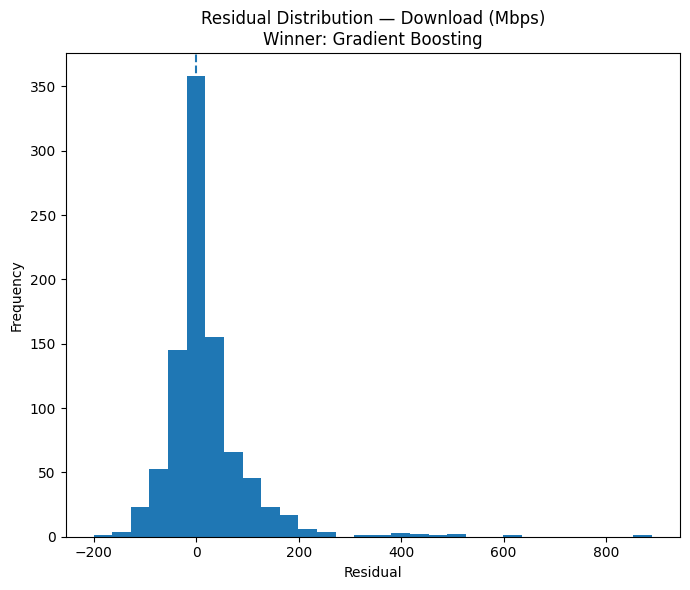

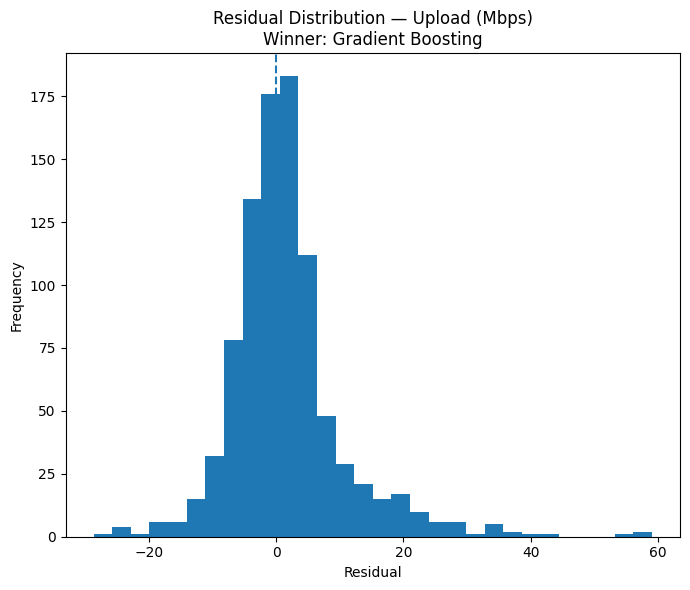

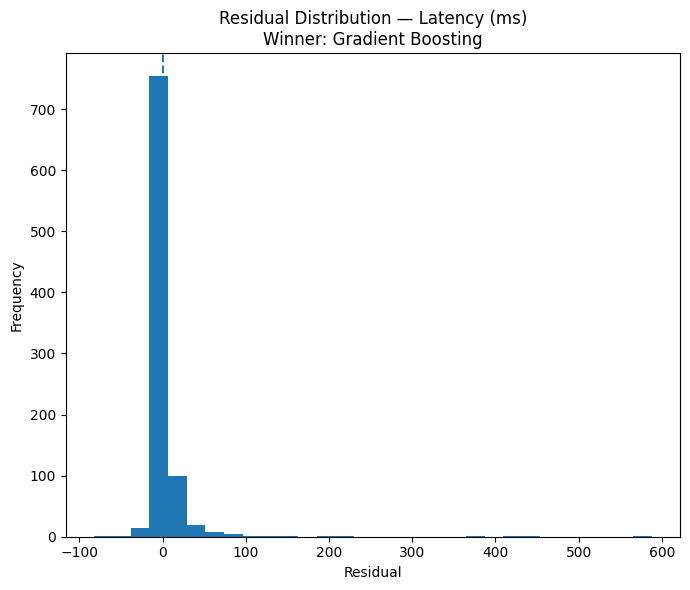

In [32]:
for i, (target, target_label) in enumerate(zip(targets, target_names)):
    y_true = y_test_df[target].values
    y_pred = test_preds[winner_name][:, i]
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 6))
    plt.hist(residuals, bins=30)
    plt.axvline(0, linestyle='--')

    plt.title(f'Residual Distribution — {target_label}\nWinner: {winner_name}')
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.tight_layout()

    safe_name = target.replace('/', '_')
    plt.savefig(os.path.join(OUTPUTS_DIR, f'winner_residual_hist_{safe_name}.png'), dpi=200, bbox_inches='tight')
    plt.show()

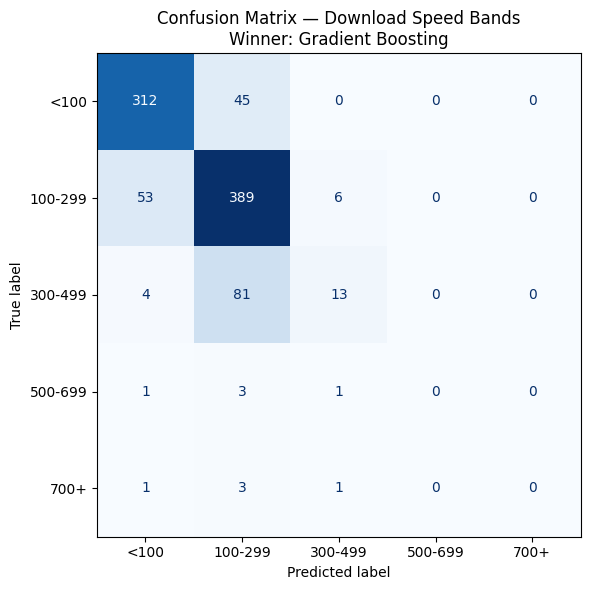

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

download_idx = targets.index('avg_d_mbps')

y_true = y_test_df['avg_d_mbps'].values
y_pred = test_preds[winner_name][:, download_idx]

bins = [0, 100, 300, 500, 700, np.inf]
labels = ['<100', '100-299', '300-499', '500-699', '700+']

y_true_class = pd.cut(y_true, bins=bins, labels=labels, include_lowest=True)
y_pred_class = pd.cut(y_pred, bins=bins, labels=labels, include_lowest=True)

cm = confusion_matrix(y_true_class, y_pred_class, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title(f'Confusion Matrix — Download Speed Bands\nWinner: {winner_name}')
plt.tight_layout()

plt.savefig(os.path.join(OUTPUTS_DIR, 'winner_confusion_matrix_download_bands.png'), dpi=200, bbox_inches='tight')
plt.show()

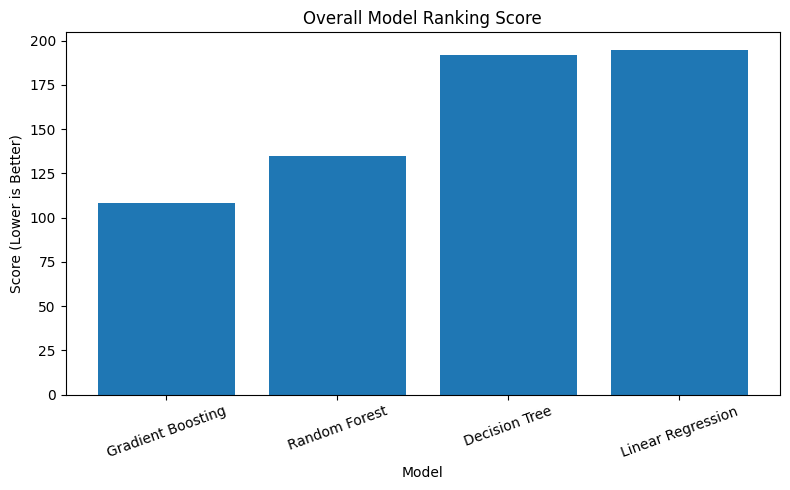

In [34]:
rank_df = pd.DataFrame(ranked, columns=['Model', 'Rank Score'])

plt.figure(figsize=(8, 5))
plt.bar(rank_df['Model'], rank_df['Rank Score'])
plt.title('Overall Model Ranking Score')
plt.xlabel('Model')
plt.ylabel('Score (Lower is Better)')
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUTS_DIR, 'overall_model_ranking_score.png'), dpi=200, bbox_inches='tight')
plt.show()

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics_order = ['RMSE', 'MAE', 'MAPE', 'R2']

rank_columns = []
rank_data = {model: [] for model in model_names}

for target in targets:
    for metric in metrics_order:
        col_name = f'{target}\n{metric}'
        rank_columns.append(col_name)

        vals = {model: all_test_metrics[model][target][metric] for model in model_names}

        reverse = (metric == 'R2')
        sorted_models = sorted(vals, key=vals.get, reverse=reverse)

        ranks = {model: rank + 1 for rank, model in enumerate(sorted_models)}

        for model in model_names:
            rank_data[model].append(ranks[model])

rank_df = pd.DataFrame(rank_data, index=rank_columns).T
rank_df

,avg_d_mbps\nRMSE,avg_d_mbps\nMAE,avg_d_mbps\nMAPE,avg_d_mbps\nR2,avg_u_mbps\nRMSE,avg_u_mbps\nMAE,avg_u_mbps\nMAPE,avg_u_mbps\nR2,avg_lat_ms\nRMSE,avg_lat_ms\nMAE,avg_lat_ms\nMAPE,avg_lat_ms\nR2
Linear Regression,2,4,4,2,2,3,2,2,4,4,4,4
Decision Tree,3,3,2,3,4,4,4,4,3,3,2,3
Random Forest,1,2,3,1,1,2,3,1,2,2,3,2
Gradient Boosting,4,1,1,4,3,1,1,3,1,1,1,1


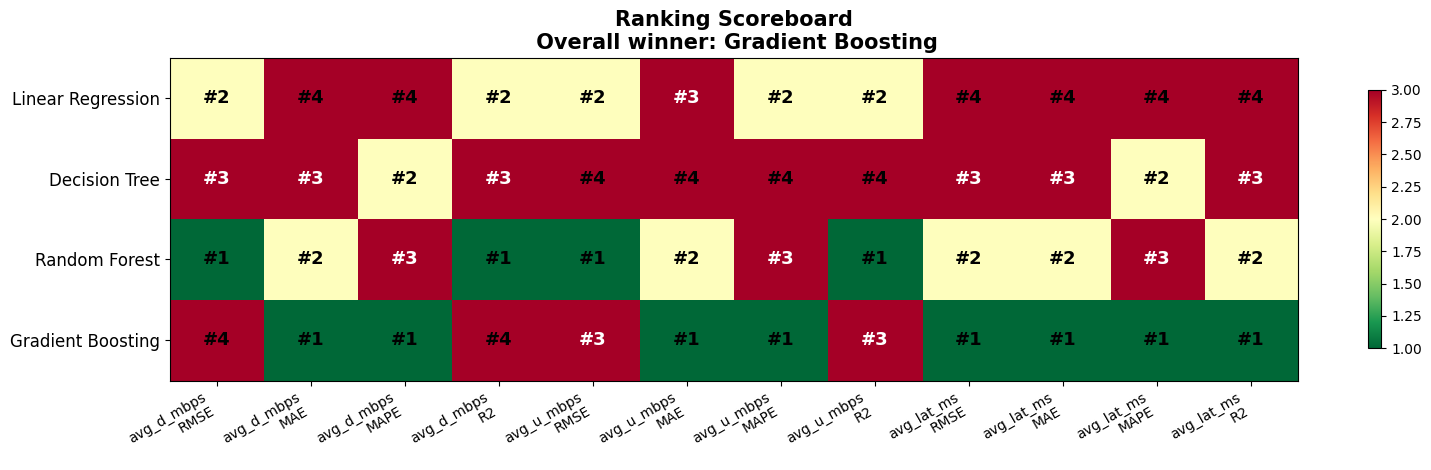

In [40]:
fig, ax = plt.subplots(figsize=(16, 4.8))

im = ax.imshow(rank_df.values, aspect='auto', cmap='RdYlGn_r', vmin=1, vmax=3)

ax.set_xticks(np.arange(rank_df.shape[1]))
ax.set_xticklabels(rank_df.columns, rotation=30, ha='right', fontsize=10)

ax.set_yticks(np.arange(rank_df.shape[0]))
ax.set_yticklabels(rank_df.index, fontsize=12)

for i in range(rank_df.shape[0]):
    for j in range(rank_df.shape[1]):
        rank_val = rank_df.iloc[i, j]
        txt_color = 'white' if rank_val == 3 else 'black'
        ax.text(
            j, i, f'#{rank_val}',
            ha='center', va='center',
            color=txt_color, fontsize=13, fontweight='bold'
        )

ax.set_title(
    f'Ranking Scoreboard\n '
    f'Overall winner: {winner_name}',
    fontsize=15, fontweight='bold'
)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'rank_scoreboard_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()

ModuleNotFoundError: No module named 'predict'